<a target="_blank" href="https://colab.research.google.com/github/AI4Finance-Foundation/FinRL-Tutorials/blob/master/1-Introduction/China_A_share_market_tushare.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Quantitative trading in China A stock market with FinRL

Install FinRL

!pip install wrds
!pip install swig
!pip install -q condacolab
import condacolab
condacolab.install()
!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git


Install other libraries

!pip install stockstats
!pip install tushare
#install talib
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz 
!tar xvzf ta-lib-0.4.0-src.tar.gz
import os
os.chdir('ta-lib') 
!./configure --prefix=/usr
!make
!make install
#!sudo make install # Sometimes it need root 
os.chdir('../')
!pip install TA-Lib

[LZ]: Change current directory to `FinRL-Meta`

In [1]:
%cd /Users/raymondl/Projects/FinRL-Meta

/Users/raymondl/Projects/FinRL-Meta


%cd /
!git clone https://github.com/AI4Finance-Foundation/FinRL-Meta
%cd /FinRL-Meta/

## Import Modules

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd 
from IPython import display

display.set_matplotlib_formats("svg")

from meta import config 
from meta.data_processor import DataProcessor 
# from main import check_and_make_directories 
from meta.data_processors.tushare import Tushare, ReturnPlotter 
from meta.env_stock_trading.env_stocktrading_China_A_shares import StockTradingEnv 
from agents.stablebaselines3_models import DRLAgent 
import os 
from typing import List 
from argparse import ArgumentParser 
from meta import config 
from meta.config_tickers import DOW_30_TICKER 
from meta.config import ( DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR, INDICATORS, TRAIN_START_DATE, TRAIN_END_DATE, TEST_START_DATE, TEST_END_DATE, TRADE_START_DATE, TRADE_END_DATE, ERL_PARAMS, RLlib_PARAMS, SAC_PARAMS, ALPACA_API_KEY, ALPACA_API_SECRET, ALPACA_API_BASE_URL, )

import pyfolio
from pyfolio import timeseries

pd.options.display.max_columns = None

print("ALL Modules have been imported!")

ALL Modules have been imported!


## Create Folders

In [4]:
import os
from pathlib import Path

''' 
use check_and_make_directories() to replace the following

if not os.path.exists("./datasets"): 
  os.makedirs("./datasets") 
if not os.path.exists("./trained_models"): 
  os.makedirs("./trained_models") 
if not os.path.exists("./tensorboard_log"): 
  os.makedirs("./tensorboard_log") 
if not os.path.exists("./results"): 
  os.makedirs("./results") 
'''

def check_and_make_directories(x:list[str]) -> None:
    tmp_dir = '/Users/raymondl/Projects/tmp'
    for directory in x:
        path = Path(tmp_dir)/directory
        path.mkdir(parents=True, exist_ok=True)


check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

## Download data, cleaning and feature engineering

In [5]:
ticker_list = ['600000.SH', '600009.SH', '600016.SH', '600028.SH', '600030.SH', '600031.SH', '600036.SH', '600050.SH', '600104.SH', '600196.SH', '600276.SH', '600309.SH', '600519.SH', '600547.SH', '600570.SH']

TRAIN_START_DATE = '2015-01-01' 
TRAIN_END_DATE= '2019-08-01' 
TRADE_START_DATE = '2019-08-01' 
TRADE_END_DATE = '2020-01-03'

TIME_INTERVAL = "1d" 
kwargs = {} 
kwargs['token'] = '27080ec403c0218f96f388bca1b1d85329d563c91a43672239619ef5' 
p = DataProcessor(data_source='tushare', start_date=TRAIN_START_DATE, end_date=TRADE_END_DATE, time_interval=TIME_INTERVAL, **kwargs)

tushare successfully connected


### Download and Clean

In [6]:
p.download_data(ticker_list=ticker_list)
p.clean_data()
p.fillna()

100%|██████████| 15/15 [00:08<00:00,  1.81it/s]

Download complete! Dataset saved to ./data/dataset.csv. 
Shape of DataFrame: (17960, 8)
Shape of DataFrame:  (18315, 8)


### Add technical indicator

In [7]:
p.add_technical_indicator(config.INDICATORS) 
p.fillna()

#print(f"p.dataframe: {p.dataframe}")

tech_indicator_list:  ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']
indicator:  macd
indicator:  boll_ub
indicator:  boll_lb
indicator:  rsi_30
indicator:  cci_30
indicator:  dx_30
indicator:  close_30_sma
indicator:  close_60_sma
Succesfully add technical indicators
Shape of DataFrame:  (18270, 17)


## Split training dataset

In [8]:
train = p.data_split(p.dataframe, TRAIN_START_DATE, TRAIN_END_DATE) 

print(f"len(train.tic.unique()): {len(train.tic.unique())}")

len(train.tic.unique()): 15


In [9]:
print(f"train.tic.unique(): {train.tic.unique()}")

train.tic.unique(): ['600000.SH' '600009.SH' '600016.SH' '600028.SH' '600030.SH' '600031.SH'
 '600036.SH' '600050.SH' '600104.SH' '600196.SH' '600276.SH' '600309.SH'
 '600519.SH' '600547.SH' '600570.SH']


In [10]:
print(f"train.head()    :\n {train.head()}")

train.head()    :
          tic        time  index   open   high    low  close  adjusted_close  \
0  600000.SH  2015-01-08     45  15.87  15.88  15.20  15.25           15.25   
0  600009.SH  2015-01-08     46  20.18  20.18  19.73  20.00           20.00   
0  600016.SH  2015-01-08     47  10.61  10.66  10.09  10.20           10.20   
0  600028.SH  2015-01-08     48   7.09   7.41   6.83   6.85            6.85   
0  600030.SH  2015-01-08     49  36.40  36.70  34.68  35.25           35.25   

       volume      macd    boll_ub    boll_lb     rsi_30      cci_30  \
0  3306271.72 -0.032571  16.617911  15.012089   6.058641 -125.593009   
0   198117.45 -0.016008  20.663897  19.736103  12.828915  -90.842491   
0  4851684.17 -0.018247  10.957604   9.997396  11.862558  -99.887006   
0  8190902.35 -0.008227   7.342000   6.743000  27.409248   36.578171   
0  6376268.69  0.032910  36.576444  33.808556  61.517448   47.947020   

        dx_30  close_30_sma  close_60_sma  
0   20.602022       15.8150  

In [11]:
print(f"train.shape: {train.shape}")

train.shape: (16695, 17)


In [12]:
train.index

Index([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
       ...
       1112, 1112, 1112, 1112, 1112, 1112, 1112, 1112, 1112, 1112],
      dtype='int64', length=16695)

Why `state_space` is length of `config.INDICATOR` plus 2 and one more extra?
initial_func[1] + close_price[s] + current_hold[s] + indicator[s*c]

In [13]:
stock_dimension = len(train.tic.unique()) 
state_space = stock_dimension * (len(config.INDICATORS) + 2) + 1 

print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 15, State Space: 151


## Train

In [14]:
env_kwargs = { "stock_dim": stock_dimension, "hmax": 1000, "initial_amount": 1000000, "buy_cost_pct": 6.87e-5, "sell_cost_pct": 1.0687e-3, "reward_scaling": 1e-4, "state_space": state_space, "action_dim": stock_dimension, "tech_indicator_list": config.INDICATORS, "print_verbosity": 1, "initial_buy": True, "hundred_each_trade": True }

e_train_gym = StockTradingEnv(df=train, **env_kwargs)

In [15]:
env_train, _ = e_train_gym.get_sb_env() 

print(f"print(type(env_train)): {print(type(env_train))}")

<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>
print(type(env_train)): None


In [16]:
env_train

### DDPG

In [17]:
agent = DRLAgent(env=env_train) 
DDPG_PARAMS = { "batch_size": 256, "buffer_size": 50000, "learning_rate": 0.0005, "action_noise": "normal", } 
POLICY_KWARGS = dict(net_arch=dict(pi=[64, 64], qf=[400, 300])) 
model_ddpg = agent.get_model("ddpg", model_kwargs=DDPG_PARAMS, policy_kwargs=POLICY_KWARGS)

trained_ddpg = agent.train_model(model=model_ddpg, tb_log_name='ddpg', total_timesteps=8000)

{'batch_size': 256, 'buffer_size': 50000, 'learning_rate': 0.0005, 'action_noise': NormalActionNoise(mu=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], sigma=[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1])}
Using cpu device
Logging to tensorboard_log/ddpg/ddpg_27
----------------------------------
| time/              |           |
|    episodes        | 4         |
|    fps             | 221       |
|    time_elapsed    | 20        |
|    total_timesteps | 4448      |
| train/             |           |
|    actor_loss      | 55.1      |
|    critic_loss     | 3.43      |
|    learning_rate   | 0.0005    |
|    n_updates       | 4347      |
|    reward          | -0.391086 |
----------------------------------


### A2C

agent = DRLAgent(env=env_train) 
model_a2c = agent.get_model("a2c")

trained_a2c = agent.train_model(model=model_a2c, tb_log_name='a2c', total_timesteps=50000)

### SAC

agent = DRLAgent(env=env_train) 
model_sac = agent.get_model("sac")

trained_sac = agent.train_model(model=model_a2c, tb_log_name='sac', total_timesteps=150000)

## Trade

In [18]:
trade = p.data_split(p.dataframe, TRADE_START_DATE, TRADE_END_DATE) 
env_kwargs = { "stock_dim": stock_dimension, "hmax": 1000, "initial_amount": 1000000, "buy_cost_pct": 6.87e-5, "sell_cost_pct": 1.0687e-3, "reward_scaling": 1e-4, "state_space": state_space, "action_dim": stock_dimension, "tech_indicator_list": config.INDICATORS, "print_verbosity": 1, "initial_buy": False, "hundred_each_trade": True } 
e_trade_gym = StockTradingEnv(df=trade, **env_kwargs)

In [19]:
trade.tail()

,tic,time,index,open,high,low,close,adjusted_close,volume,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma
103,600276.SH,2020-01-02,18295,88.00,88.10,86.85,87.68,87.68,210809.91,-0.345742,87.726881,82.918119,53.727892,55.084385,0.269908,86.140333,87.454167
103,600309.SH,2020-01-02,18296,56.50,57.60,55.69,55.89,55.89,213379.65,1.824002,56.464963,49.288037,67.318349,154.362552,40.644388,51.418667,48.306667
103,600519.SH,2020-01-02,18297,1128.00,1145.06,1116.00,1130.00,1130.00,148099.16,-3.944016,1188.194602,1121.743398,46.814398,-98.839848,14.531247,1158.660667,1175.338000
103,600547.SH,2020-01-02,18298,32.31,32.96,32.26,32.90,32.90,489106.37,0.348359,32.722690,30.612310,52.089075,155.084385,9.413476,31.288667,31.498333
103,600570.SH,2020-01-02,18299,78.81,79.98,77.96,79.44,79.44,175683.22,0.576198,81.327750,73.235250,54.957562,97.011383,14.846227,76.178000,76.136500


In [20]:
df_account_value, df_actions = DRLAgent.DRL_prediction(model=trained_ddpg, environment=e_trade_gym)

temp_env, _ = e_trade_gym.get_sb_env()
temp_df = temp_env.env_method(method_name="save_asset_memory")

df_actions.to_csv("action.csv", index=False) 
print(f"df_actions: {df_actions}")

## Backtest

### matplotlib inline

In [21]:
df_account_value =(df_account_value[["date", "total_asset"]]
                   .rename(columns={"total_asset": "account_value"})
                   .set_index('date')
                   .sort_index()
                )
        

In [22]:
trade.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1560 entries, 0 to 103
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tic             1560 non-null   object 
 1   time            1560 non-null   object 
 2   index           1560 non-null   int64  
 3   open            1560 non-null   float64
 4   high            1560 non-null   float64
 5   low             1560 non-null   float64
 6   close           1560 non-null   float64
 7   adjusted_close  1560 non-null   float64
 8   volume          1560 non-null   float64
 9   macd            1560 non-null   float64
 10  boll_ub         1560 non-null   float64
 11  boll_lb         1560 non-null   float64
 12  rsi_30          1560 non-null   float64
 13  cci_30          1560 non-null   float64
 14  dx_30           1560 non-null   float64
 15  close_30_sma    1560 non-null   float64
 16  close_60_sma    1560 non-null   float64
dtypes: float64(14), int64(1), object(2)
mem

In [23]:
trade.head()

,tic,time,index,open,high,low,close,adjusted_close,volume,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma
0,600000.SH,2019-08-01,16740,11.76,11.85,11.63,11.65,11.65,324717.02,0.061723,11.954291,11.217709,51.629338,30.105973,10.079146,11.632667,11.516667
0,600009.SH,2019-08-01,16741,82.78,83.46,81.60,82.01,82.01,72583.66,1.456486,85.100887,78.654113,57.259597,28.697822,25.497226,81.707000,76.533333
0,600016.SH,2019-08-01,16742,6.04,6.06,6.01,6.02,6.02,517116.83,-0.045649,6.088116,5.935884,43.258474,-43.433030,5.776892,6.139667,6.162500
0,600028.SH,2019-08-01,16743,5.25,5.27,5.21,5.23,5.23,616872.58,-0.030634,5.362514,5.179486,42.928615,-77.147867,15.828431,5.324333,5.357333
0,600030.SH,2019-08-01,16744,23.09,23.19,22.81,22.92,22.92,809710.56,0.143135,23.703768,22.720232,51.752238,-102.582689,13.330013,23.385667,21.918333


In [24]:
trade['time'] = pd.to_datetime(trade['time'])

In [25]:
trade.dtypes

tic                       object
time              datetime64[ns]
index                      int64
open                     float64
high                     float64
low                      float64
close                    float64
adjusted_close           float64
volume                   float64
macd                     float64
boll_ub                  float64
boll_lb                  float64
rsi_30                   float64
cci_30                   float64
dx_30                    float64
close_30_sma             float64
close_60_sma             float64
dtype: object

In [34]:
trade.time.is_monotonic_increasing

True

In [35]:
trade.time.head()

0   2019-08-01
0   2019-08-01
0   2019-08-01
0   2019-08-01
0   2019-08-01
Name: time, dtype: datetime64[ns]

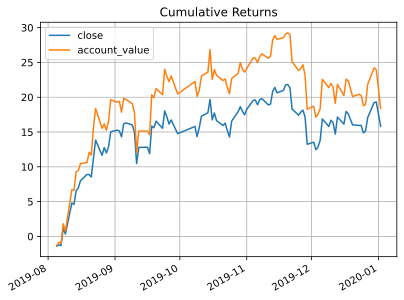

In [36]:
%matplotlib inline
plotter = ReturnPlotter(df_account_value, trade, TRADE_START_DATE, TRADE_END_DATE)
plotter.plot()

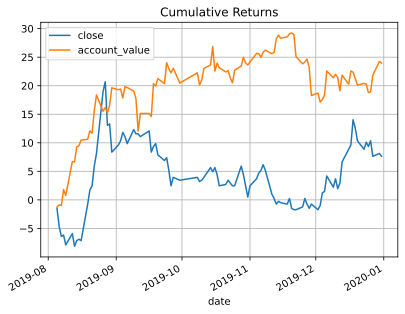

In [37]:
# ticket: SSE 50：000016
plotter.plot("000016.SZ")

### CSI 300

In [27]:
baseline_df = plotter.get_baseline("399300.SZ")
baseline_df = baseline_df.rename(columns={'dt': 'date'})

In [ ]:
daily_return = plotter.get_return(df_account_value)
daily_return_base = plotter.get_return(baseline_df, value_col_name="close")

perf_func = timeseries.perf_stats 
perf_stats_all = perf_func(returns=daily_return, factor_returns=daily_return_base, positions=None, transactions=None, turnover_denom="AGB")
print("==============DRL Strategy Stats===========")
print(f"perf_stats_all: {perf_stats_all}")

In [ ]:
daily_return = plotter.get_return(df_account_value)
daily_return_base = plotter.get_return(baseline_df, value_col_name="close")

perf_func = timeseries.perf_stats
perf_stats_all = perf_func(returns=daily_return_base, factor_returns=daily_return_base, positions=None, transactions=None, turnover_denom="AGB")

print("==============Baseline Strategy Stats===========")

print(f"perf_stats_all: {perf_stats_all}")